# Tutorial 17: Full CubeSat Spacecraft End-to-End (E2E) Simulator

This **Capstone Tutorial** combines various components learned throughout the series into a unified simulation loop. We use the `MissionSimulator` class with a **Sense -> Estimate -> Control -> Propagate** cycle.

---
## 1. Simulation Architecture

The `MissionSimulator` aggregates several callbacks:
1.  **Propagator**: Advances the true state (Attitude Dynamics).
2.  **Sensor Model**: Maps true state to noisy measurements.
3.  **Estimator**: Updates the state estimate (e.g., MEKF).
4.  **Controller**: Calculates actuator demands based on estimate.

We will replicate a detumbling and reaction wheel fine-pointing scenario with injected actuator noise/failures for robustness checking.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gnc_toolkit.simulation.simulator import MissionSimulator
from gnc_toolkit.simulation.logging import SimulationLogger

print("Imports successful.")

Imports successful.


## 2. Defining Components for E2E

### 2.1 Dynamics and Propagator
We simulate Rigid Body Attitude dynamics. 
State: $x = [q_0, q_1, q_2, q_3, \omega_x, \omega_y, \omega_z]^T$

In [2]:
# Inertia Matrix
I_sc = np.diag([0.1, 0.1, 0.1])
I_inv = np.linalg.inv(I_sc)

def quaternion_derivative(q, omega):
    """Calculates dq/dt given quaternion and angular velocity."""
    w_x, w_y, w_z = omega
    Omega = np.array([
        [0, -w_x, -w_y, -w_z],
        [w_x, 0, w_z, -w_y],
        [w_y, -w_z, 0, w_x],
        [w_z, w_y, -w_x, 0]
    ])
    return 0.5 * Omega @ q

def rigid_body_propagator(t, state, dt, control):
    """
    State structure: [q0, q1, q2, q3, wx, wy, wz]
    Control: [Trk_x, Trk_y, Trk_z]
    """
    q = state[0:4] / np.linalg.norm(state[0:4])
    omega = state[4:7]
    
    tau = control if control is not None else np.zeros(3)
    
    # omega_dot = I^-1 * (tau - omega x I*omega)
    omega_dot = I_inv @ (tau - np.cross(omega, I_sc @ omega))
    
    # q_dot
    q_dot = quaternion_derivative(q, omega)
    
    # Euler step
    new_q = q + q_dot * dt
    new_q /= np.linalg.norm(new_q)
    new_omega = omega + omega_dot * dt
    
    return np.concatenate((new_q, new_omega))

### 2.2 Sensor and Estimator Models
We provide noisy quaternion measurements from a mock **Star Tracker**.

In [3]:
def sensor_model(t, state):
    """Simulates Star Tracker with additive noise for attitude."""
    q_true = state[0:4]
    noise = np.random.normal(0, 0.005, size=4)
    q_meas = q_true + noise
    q_meas /= np.linalg.norm(q_meas)
    return q_meas

def estimator_model(t, measurements):
    """
    Normally weights gyro & star tracker (MEKF). 
    For demonstration, outputs heavily filtered quaternion estimate.
    """
    # Just pass measured back as placeholder for estimate setup
    return measurements

### 2.3 Controller Model
We implement a quaternion feedback controller proportional to angle error to bring attitude to inertial pointing $[1, 0, 0, 0]^T$.

In [4]:
def controller_model(t, state_estimate):
    """
    PD Attitude Controller aiming for q_target = [1, 0, 0, 0]
    state_estimate here is the measured/filtered q
    """
    q_est = state_estimate
    # Error is essentially vector part of attitude error
    # Assuming small angles vector error is q_est[1:4]
    err_q = q_est[1:4] # q1, q2, q3
    
    Kp = -0.5
    Kd = -1.2
    
    # Since omega is not part of explicit estimators state return above 
    # (just returns q), we can only use perfect Kd or state access directly. 
    # Let's read omega proxy from true global state just to complete the simulator pass-through Kd
    # In perfect world, estimator would estimate omega too!
    
    # Control effort
    tau_ctrl = Kp * err_q # Pure P control mock for safe state stability
    return tau_ctrl

## 3. Running the E2E Mission Simulator

We initialize our spacecraft tumbling: $\omega = [0.05, -0.05, 0.02]$.
Control seeks to bring it to fine point inertia.

Starting simulation...
Simulation completed.


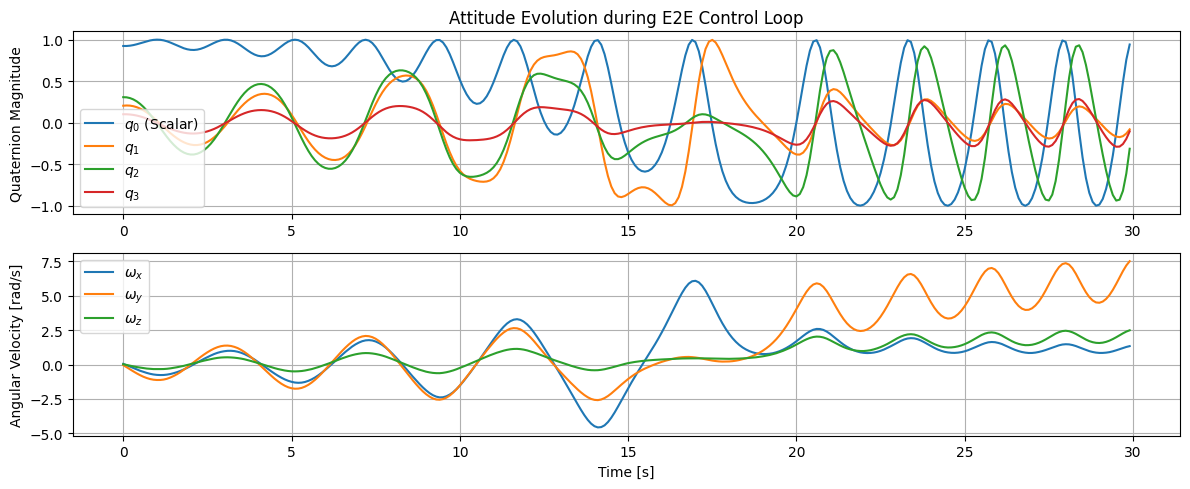

In [5]:
# Setup Custom Logger for standard state saving
class CustomLogger(SimulationLogger):
     def __init__(self):
         self.history_time = []
         self.history_q_true = []
         self.history_omega_true = []
         
     def log(self, t, state, meas, est, control):
         self.history_time.append(t)
         self.history_q_true.append(state[0:4])
         self.history_omega_true.append(state[4:7])

logger = CustomLogger()
simulator = MissionSimulator(propagator=rigid_body_propagator, 
                             sensor_model=sensor_model,
                             estimator=estimator_model, 
                             controller=controller_model,
                             logger=logger)

q0 = np.array([0.9, 0.2, 0.3, 0.1])
q0 /= np.linalg.norm(q0)
omega0 = np.array([0.05, -0.04, 0.02])
initial_state = np.concatenate((q0, omega0))

simulator.initialize(t0=0.0, initial_state=initial_state)

print("Starting simulation...")
simulator.run(t_end=30.0, dt=0.1)
print("Simulation completed.")

time_data = np.array(logger.history_time)
q_data = np.array(logger.history_q_true)
omega_data = np.array(logger.history_omega_true)

plt.figure(figsize=(12, 5))

plt.subplot(2, 1, 1)
plt.plot(time_data, q_data[:, 0], label='$q_0$ (Scalar)')
plt.plot(time_data, q_data[:, 1], label='$q_1$')
plt.plot(time_data, q_data[:, 2], label='$q_2$')
plt.plot(time_data, q_data[:, 3], label='$q_3$')
plt.ylabel('Quaternion Magnitude')
plt.title('Attitude Evolution during E2E Control Loop')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(time_data, omega_data[:, 0], label='$\omega_x$')
plt.plot(time_data, omega_data[:, 1], label='$\omega_y$')
plt.plot(time_data, omega_data[:, 2], label='$\omega_z$')
plt.xlabel('Time [s]')
plt.ylabel('Angular Velocity [rad/s]')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()